# Hur man genererar grafer
Nedan följer hur panda och matplotlib kan användas för att skapa grafer från en fil genererad från phyphox

In [ ]:
#%pip install pandas matplotlib numpy
%pip install --upgrade pip matplotlib pandas jupyter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('dark_background')

df = pd.read_csv("test.txt", comment='#')
nr_of_columns = len(df.columns[1:])
fig, ax = plt.subplots(nr_of_columns, 1, dpi=300)
# Alternatives: 'seaborn-v0_8-whitegrid', 'tableau-colorblind10', 'bmh', 'ggplot', 'dark_background'

avg_amount = 10
colors = ['red', 'green', 'blue', 'magenta']
#major_ticks = np.arange(-1.5,1.5,0.5)
#minor_ticks = np.arange(-1.5,1.5,0.1)

x = df['time']
for col_name, graph, color in zip(df.columns[1:], ax, colors):
    y = df[col_name]
    y_smooth = df[col_name].rolling(window=avg_amount, center=True).mean()

    # Visualize
    graph.plot(x, y, '--', label='Raw', alpha=0.4, color=color)
    graph.plot(x, y_smooth, label='Avg', alpha=1, color=color)
    graph.set_title(col_name)
    graph.minorticks_on()
    #graph.legend(frameon=True, facecolor='white', framealpha=0.9, edgecolor='none', loc='upper right')
    graph.grid(color='white', alpha=0.3)


plt.tight_layout()
plt.show()

# Random stuff

In [ ]:
# Uppgift 1
def Uppgift1():
    a=3
    b=7
    print(f"a={a}, b={b}")
    temp = a
    a = b
    b=temp
    print(f"a={a}, b={b}")

# Uppgift 2
def Uppgift2():
    s = 0
    for i in range(1, 90, 2):
        s += i
    print(f"Sum of odd numbers from 1 to (including) 89: {s}")
    print(f"Different method gives: {sum(list(range(1,90,2)))}")
# Uppgift 3
def Uppgift3():
    a_first=0
    a_second=1
    for i in range(2,21):
        a_next = a_first + a_second
        print(f"a{i}: {a_next}")
        a_first = a_second
        a_second = a_next

Uppgift1()
Uppgift2()
Uppgift3()

In [ ]:
s = 0
s = sum(list(range(1,90,2)))
print(s)

In [ ]:
def sum_generator():
    # Start values
    n = 1
    val = 0
    # Loop with yield
    while True:
        val += (1/3)**n
        n += 1
        yield val

gen = sum_generator()

(previous, current) = (-10000, 0)
while current - previous>1e-16:
    previous = current
    current = next(gen)
    print(current)
print("Final value was ", current)




### Inlämningsuppgift 1:
(Uppgift 3.31 i boken.) Skriv ett program som iterera från 2 till 100 för varje tal serien bestämmer och skriver ut om det är ett primtal.

Om ett tal n är ett primtal, kan det bestämmas genom att man dividerar detta med alla tal från 2 till sqrt(n). Om någon rest av divisionen blir 0, är n inget primtal. Resten av en division kan bestämmas med modullo-operatorn % i Python. Använd break för att avbryta en loop när resten blir 0.

In [ ]:
from math import *

def is_prime(value):
    for i in range(2, 1 + ceil(sqrt(value))): # För typ 9 ska den delas med 2, 3. För att få inklusive 3 måste vi ha 1+ceil
        if value % i == 0: # If any modulo has no rest, it's NOT prime
            return False
    return True

assert(is_prime(1))
assert(is_prime(3))
assert(is_prime(5))
assert(is_prime(7))
assert(not is_prime(9))
assert(not is_prime(12))
assert(is_prime(13))
assert(is_prime(47))
assert(not is_prime(48))

# Program
for i in range(2, 100):
    if is_prime(i):
        print(f"{i} is a prime number.")


### Inlämningsuppgift 2:
Använd Python för att lösa minst tre uppgifter från valfritt nationellt prov. Du skall använda loop i minst en av uppgifterna.

Skriv även in uppgiftens frågeformulering i filen så att den som får filen förstår vilken uppgift du löst.När du gör detta behöver du ändra cellen typ till Markdown. Du kan du välja att prova att använda LaTex, ett språk för att skriva matematik. Ett uttryck omgivet av dollartecken tolkas som LaTex, tex ger **\int_2^3 f(x) dx**  följande: $\int_2^3 f(x) dx$

In [ ]:
# NP-uppgift 1 (med loop)
"""
2022 ma1c
Jonas ska borra ett hål för bergvärme och behöver borra ner till djupet 125 m.
Lutningen på borrhålet måste vara 10,0° enligt en borrplan.

a) Hur långt borrhål måste Jonas minst borra?

Höjden är 125m, vinkeln 10 grader, och den sökta längden är motstående katet.

cos(10) = 125/x
genom att skriva om på följande sätt kan vi hitta nollstället:
0 = 125/x - cos(10)
f(x) = 125/x - cos(10)
"""

# numerical derivative
def num_der(func, x, step): # central derivative. Reducerar tydligen komplexitet (jämfört med den vanliga forward derivative), men hur är lite bortom mig.
    return (func(x+step) - func(x-step))/(2*step)

# Hittar ett nollställe till funktion (alltså vilket x löser f(x)=0)
# Kallas newton-raphson
def find_root(func, initial_guess, allowed_error):
    step = 1e-8
    error = 1e16
    x_n = initial_guess
    x_np1 = -1
    while error>allowed_error:
        x_np1 = x_n - func(x_n) / num_der(func, x_n, step)
        error = x_np1 - x_n
        x_n = x_np1
    return x_n

def function_NP1(x):
    return (125/x) - cos(10*pi/180) # 10 grader konverterat till radianer

root = find_root(function_NP1, 1, 1e-10)
print(f"Lösning på NP uppgift 1: Hålet som Jonas ska borra måste vara {round(root,2)} m långt")
# Ger ungefär 127 m långt måste det borras


# NP-uppgift 2
"""
Stina har satt in pengar på ett bankkonto med fast årsränta. Följande funktion
kan användas för att beräkna hur mycket pengar, i kronor, som finns på bankkontot:

f(x) = 10000*1.04^x

där x är antal år efter att hon har satt in pengarna på bankkontot.

a) Vilken räntesats fick hon av banken?
b) Beräkna f(5)
"""
def function_NP2(x):
    return 10000*(1.04**x)

# f(5) = function_NP2(5)
print(f"Lösning på NP uppgift 2: Funktionens värde är {round(function_NP2(5),2)}")


# NP-uppgift 3
"""
Moa har en bil som hon köpt för 230 000 kr. Hon säljer bilen
efter 6 år för 157 000 kr. Hur mycket har bilens värde
minskat procentuellt i genomsnitt per år?
"""

# På samma sätt som för första uppgiften kan man konstruera en funktion f(x) och lösa f(x) = 0.
# 230000*x^6 = 157000
# 230000*x^6 - 157000 = 0
# Funktionen vi löser med newton-raphson är f(x) = 230000*x^6 - 157000

solution_3 = find_root(lambda x : 230000*(x**6) - 157000, 0.9, 1e-10)

# Ger en förändringsfaktor. Vi snyggar till resultatet med en faktisk procentuell minskning
solution_3 = 100*(1-solution_3)
print(f"Lösning på NP uppgift 3: Bilens värde minskar med {round(solution_3,2)}% per år")
#


### Inlämningsuppgift 3:
Använd en loop för att rita en uppsättning med koncentriska cirklar med minskande radier så att det framstår som att man tittar in i ett långt rör.

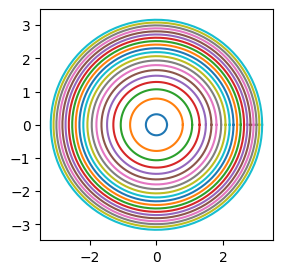

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from math import *

def circular_to_cartesian(r, v) -> tuple[float,float]:
    return (r*cos(v),r*sin(v))

res = 100
nr_of_rings = 20

ANGLE = np.linspace(0,2*pi, res)
r_list = np.linspace(0.1,10,nr_of_rings)**(1/2) # så det inte blir jämnt avstånd mellan varje. Förbättrar illusionen en aning
plt.figure(figsize=(3,3))
for r in r_list:
    points = [circular_to_cartesian(r,v) for v in ANGLE]
    X = [point[0] for point in points]
    Y = [point[1] for point in points]
    plt.plot(X,Y)

### Inlämningsuppgift 4:
Skapa en funktion som kan användas under fredagseftermiddagarna för att slumpa fram vem som skall presentera. 

In [75]:
elever = ["a", "b", "c", "d", "e"]

import random as rand

random_index = rand.randint(0,len(elever) - 1)
print(f"Det är dags för {elever[random_index]} att presentera!")

Det är dags för d att presentera!
